# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hashir9099/flyrank-ml/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import os
if not os.path.exists("flyrank-ml"):
    !git clone https://github.com/Hashir9099/flyrank-ml.git
os.chdir("flyrank-ml")
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape)

Cloning into 'flyrank-ml'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 201 (delta 86), reused 100 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (201/201), 1.91 MiB | 10.50 MiB/s, done.
Resolving deltas: 100% (86/86), done.
(30000, 44)


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Looking at the distribution of key fields before drawing any conclusions from them —
especially checking for heavy tails that could distort averages or a naive threshold rule.

       search_volume    word_count  impressions_90d    clicks_90d  \
count   27532.000000  22301.000000     30000.000000  30000.000000   
mean      158.882391   3107.760325      5200.366300     16.097333   
std      1518.270825   1452.382598     16838.019547     75.076958   
min         0.000000      8.000000         1.000000      0.000000   
25%         0.000000   2413.000000        81.000000      0.000000   
50%        10.000000   2877.000000       731.000000      1.000000   
75%        20.000000   3666.000000      3615.250000      7.000000   
max     74000.000000   9546.000000    517715.000000   4178.000000   

                ctr  avg_position  engagement_rate  content_age_days  
count  30000.000000   30000.00000     30000.000000       30000.00000  
mean       0.510733      16.34238         2.534520         256.16780  
std        3.279162      15.21679         8.310096         132.70793  
min        0.000000       0.00000         0.000000          90.00000  
25%        0.000000    

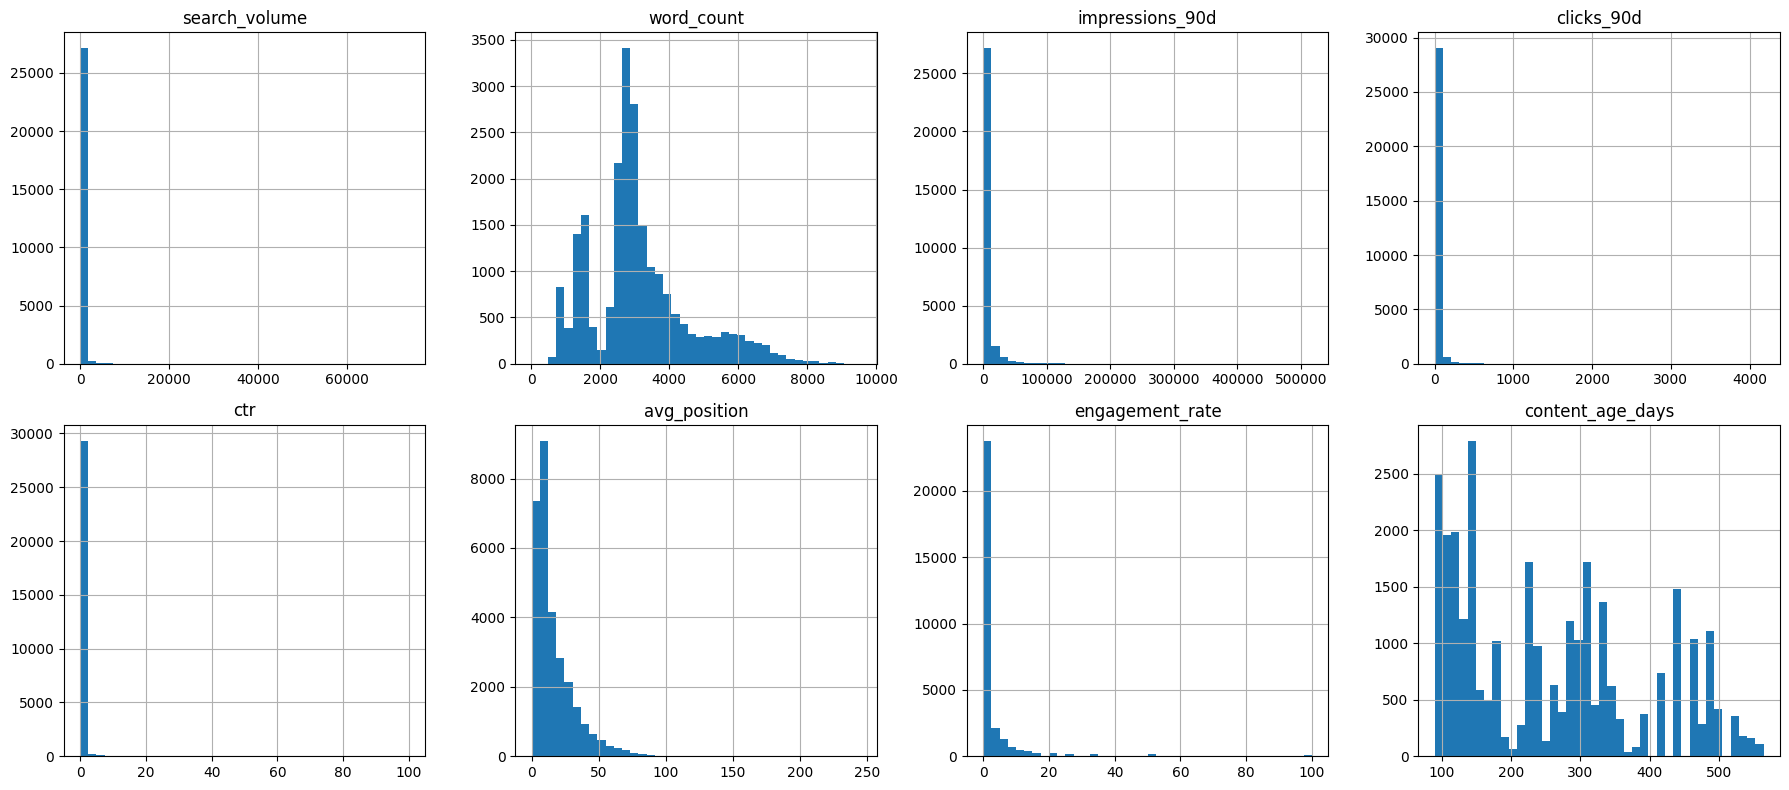

In [6]:
import matplotlib.pyplot as plt

key_fields = ["search_volume", "word_count", "impressions_90d", "clicks_90d",
              "ctr", "avg_position", "engagement_rate", "content_age_days"]

print(df[key_fields].describe())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, key_fields):
    df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Three signals tested against the decline label (`trend_direction == "down"`):

1. **Older content declines more than fresh content** — verdict: [CONFIRMED / OPPOSITE / MIXED / FALSE]
2. **Longer content (word_count) declines less** — verdict: [CONFIRMED / OPPOSITE / MIXED / FALSE]
3. **Lower engagement_rate is associated with decline** — verdict: [CONFIRMED / OPPOSITE / MIXED / FALSE]

In [7]:
is_declining = df["trend_direction"] == "down"

# signal 1: age vs decline
print("Signal 1 — content_age_days by trend_direction:")
print(df.groupby("trend_direction")["content_age_days"].median())

# signal 2: word_count vs decline
print("\nSignal 2 — word_count by trend_direction:")
print(df.groupby("trend_direction")["word_count"].median())

# signal 3: engagement_rate vs decline
print("\nSignal 3 — engagement_rate by trend_direction:")
print(df.groupby("trend_direction")["engagement_rate"].median())

Signal 1 — content_age_days by trend_direction:
trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        291.5
Name: content_age_days, dtype: float64

Signal 2 — word_count by trend_direction:
trend_direction
down      2909.0
flat      2698.5
new       2239.0
stable    2912.5
up        2847.5
Name: word_count, dtype: float64

Signal 3 — engagement_rate by trend_direction:
trend_direction
down      0.0
flat      0.0
new       0.0
stable    0.0
up        0.0
Name: engagement_rate, dtype: float64


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Testing the assumption behind FlyRank's freshness flag: that content flagged "stale"
(`freshness_tier`) is more likely to be declining. If the assumption holds, declining rate
should be visibly higher in the stalest tier than the freshest one.

In [8]:
print(df.groupby("freshness_tier")["trend_direction"].value_counts(normalize=True).unstack().round(3))

trend_direction   down   flat    new  stable     up
freshness_tier                                     
0-30             0.511  0.044  0.104   0.186  0.155
181+             0.471  0.092  0.144   0.138  0.155
31-90            0.589  0.006  0.040   0.149  0.217
91-180           0.611  0.026  0.008   0.229  0.126


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

[Signal that held up] is the strongest observed driver of decline in this sample — a content
team could reasonably prioritize [action] for pages showing that pattern. [Signal that didn't
hold] should NOT be used as a standalone rule, since the data doesn't support it here. These
are observed, directional patterns in this 30k-row sample — not causal claims about how
Google's ranking algorithm works.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.